In [1]:
# Import dependencies

import pandas as pd

import matplotlib.pyplot as plt

import numpy as np


In [2]:
# Create a set of random latitude and longitude combinations.

lats = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lngs = np.random.uniform(low=-90.000, high=90.000, size = 1500)

lat_lngs = zip(lats, lngs)

lat_lngs

In [3]:
# Add the latitudes and longitudes to a list.

coordinates = list(lat_lngs)
coordinates

[(80.10109180805907, -72.72529912261214),
 (-4.7092765440211934, 11.088731505277067),
 (-11.014677438664961, -83.77865460019152),
 (-19.459438286135082, -71.92665506292768),
 (43.25402412164715, -55.563428071633034),
 (27.529182147679933, -39.79610284008127),
 (-81.08368716980031, -0.25237571084370813),
 (84.02567428465233, -20.14816255102444),
 (-21.274474461638377, 80.53179750246238),
 (-16.372639493431166, -59.785827656589746),
 (-88.11736709801487, 78.2435350997334),
 (20.301113525831198, 46.513238080403084),
 (-30.78091755154847, -19.556428358029947),
 (-38.51364266017542, 0.7867416115492176),
 (-14.477122534829562, -15.143149223093033),
 (-15.384054462582014, -18.07201259448179),
 (-15.7105105911036, 30.8088631746366),
 (30.19144535553164, -74.98814811681459),
 (-72.23748923940545, -57.9912048779692),
 (-74.08902253199163, 19.016270240070895),
 (-70.7859778319694, -54.085204456760266),
 (48.23891838975891, 42.03633675063969),
 (-57.52518935917294, -7.2955556472789596),
 (63.65338

In [4]:
from citipy import citipy


In [5]:
# Create a list fo holding the cities.

cities = []

# Identify the nearest city for each latitude and longitude combination.

for coordinate in coordinates:
    
    city = citipy.nearest_city(coordinate[0], coordinate[1]).city_name
    
    # If the city is unique, then we will add it to the cities list.
    
    if city not in cities:
        
        cities.append(city)
        
# Print the city count to confirm sufficient count.

len(cities)
    
    

593

In [6]:
# Import the requests library.

import requests

# Import the API key.

from config import weather_api_key

In [7]:
# Import the time library and the datetime module from the datetime library.

import time

from datetime import datetime

In [8]:
# Start URL for Weather Map API Call.

url = "https://api.openweathermap.org/data/2.5/weather?units=Imperal&APPID=" + weather_api_key

In [9]:
# Create and empty list to hold hte weather data.

city_data = []

# Print the beginning of the logging.

print("Beginning Data Retrieval      ")
print("------------------------------")

# Create counters.

record_count = 1
set_count = 1


# Loop through all the cities in the list.

for i, city in enumerate(cities):
    
    
    # Group cities in sets of 50 for logging purposes
    
    if (i % 50 == 0 and i >= 50):
        
        set_count += 1
        
        record_count = 1
        
        time.sleep(60)
        
        
    # Create endpoint URL with each city.
    
    city_url = url + "&q=" + city.replace(" ", "+")
    
    
    # Log the URL, record, and set numbers and the city.
    
    print(f"Processing Record {record_count} of Set {set_count} | {city}")
    
    # Add 1 to the record count.
    
    record_count +=1
    
    # Run an API request for each of the cities.
    
    try:
        # Parse out the JSON and retrieve data.
        
        city_weather = requests.get(city_url).json()
        
        # Parse out the needed data.
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = datetime.utcfromtimestamp(city_weather["dt"]).strftime('%Y-%m-%d %H:%M:%S') 

        # Append the City information into city_data list
        city_data.append({"City": city.title(), 
                          "Lat": city_lat, 
                          "Lng": city_lng, 
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})
    
    except:
        print('City not found. Skipping....')
        pass
# Indicate that Data Loading is complete.
                                              
print("------------------------------")
print("Data Retrieval Complete.      ")
print("------------------------------")

Beginning Data Retrieval      
------------------------------
Processing Record 1 of Set 1 | qaanaaq
Processing Record 2 of Set 1 | loandjili
Processing Record 3 of Set 1 | chicama
Processing Record 4 of Set 1 | arica
Processing Record 5 of Set 1 | saint-pierre
Processing Record 6 of Set 1 | ribeira grande
Processing Record 7 of Set 1 | hermanus
Processing Record 8 of Set 1 | illoqqortoormiut
City not found. Skipping....
Processing Record 9 of Set 1 | hithadhoo
Processing Record 10 of Set 1 | san rafael
Processing Record 11 of Set 1 | busselton
Processing Record 12 of Set 1 | najran
Processing Record 13 of Set 1 | jamestown
Processing Record 14 of Set 1 | saldanha
Processing Record 15 of Set 1 | georgetown
Processing Record 16 of Set 1 | luangwa
Processing Record 17 of Set 1 | marsh harbour
Processing Record 18 of Set 1 | ushuaia
Processing Record 19 of Set 1 | bredasdorp
Processing Record 20 of Set 1 | morozovsk
Processing Record 21 of Set 1 | cape town
Processing Record 22 of Set 1 |

Processing Record 40 of Set 4 | pinheiro machado
Processing Record 41 of Set 4 | urdoma
Processing Record 42 of Set 4 | lagoa
Processing Record 43 of Set 4 | mahadday weyne
City not found. Skipping....
Processing Record 44 of Set 4 | betafo
Processing Record 45 of Set 4 | kortkeros
Processing Record 46 of Set 4 | horodyshche
Processing Record 47 of Set 4 | krasnoselkup
Processing Record 48 of Set 4 | derzhavinsk
Processing Record 49 of Set 4 | koutiala
Processing Record 50 of Set 4 | podor
Processing Record 1 of Set 5 | carnarvon
Processing Record 2 of Set 5 | montecristi
Processing Record 3 of Set 5 | varena
Processing Record 4 of Set 5 | komsomolsk
Processing Record 5 of Set 5 | illapel
Processing Record 6 of Set 5 | walvis bay
Processing Record 7 of Set 5 | mikkeli
Processing Record 8 of Set 5 | estelle
Processing Record 9 of Set 5 | makat
Processing Record 10 of Set 5 | harper
Processing Record 11 of Set 5 | porto novo
Processing Record 12 of Set 5 | saryshagan
City not found. Skip

Processing Record 30 of Set 8 | tumannyy
City not found. Skipping....
Processing Record 31 of Set 8 | barentu
Processing Record 32 of Set 8 | san lazaro
Processing Record 33 of Set 8 | luderitz
Processing Record 34 of Set 8 | ayagoz
Processing Record 35 of Set 8 | labrea
Processing Record 36 of Set 8 | mizpe ramon
City not found. Skipping....
Processing Record 37 of Set 8 | mutis
Processing Record 38 of Set 8 | caravelas
Processing Record 39 of Set 8 | ugoofaaru
Processing Record 40 of Set 8 | bawku
Processing Record 41 of Set 8 | floro
Processing Record 42 of Set 8 | tucuman
Processing Record 43 of Set 8 | wa
City not found. Skipping....
Processing Record 44 of Set 8 | inongo
Processing Record 45 of Set 8 | tocopilla
Processing Record 46 of Set 8 | verkhnetulomskiy
Processing Record 47 of Set 8 | plettenberg bay
Processing Record 48 of Set 8 | sinkat
City not found. Skipping....
Processing Record 49 of Set 8 | yorito
Processing Record 50 of Set 8 | monrovia
Processing Record 1 of Set 

Processing Record 16 of Set 12 | shihezi
Processing Record 17 of Set 12 | strezhevoy
Processing Record 18 of Set 12 | shakiso
Processing Record 19 of Set 12 | ndioum
Processing Record 20 of Set 12 | road town
Processing Record 21 of Set 12 | palitana
Processing Record 22 of Set 12 | baneh
Processing Record 23 of Set 12 | elizabeth city
Processing Record 24 of Set 12 | clarence town
Processing Record 25 of Set 12 | kashin
Processing Record 26 of Set 12 | remedios
Processing Record 27 of Set 12 | beloha
Processing Record 28 of Set 12 | mariestad
Processing Record 29 of Set 12 | izoplit
Processing Record 30 of Set 12 | pangoa
Processing Record 31 of Set 12 | angoche
Processing Record 32 of Set 12 | chimbote
Processing Record 33 of Set 12 | skelleftea
Processing Record 34 of Set 12 | umzimvubu
City not found. Skipping....
Processing Record 35 of Set 12 | safaga
Processing Record 36 of Set 12 | bam
Processing Record 37 of Set 12 | buritis
Processing Record 38 of Set 12 | kankon
Processing R

In [10]:
len(city_data)

552

In [11]:
# Convert the array of dictionaries to a Pandas DataFrame.

city_data_df = pd.DataFrame(city_data)

city_data_df.head(10)

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,Qaanaaq,77.4840,-69.3632,274.97,85,82,1.05,GL,2022-06-20 01:25:58
1,Loandjili,-4.7561,11.8578,295.21,94,20,2.06,CG,2022-06-20 01:25:59
2,Chicama,-7.8447,-79.1469,288.45,83,27,2.91,PE,2022-06-20 01:25:59
3,Arica,-18.4750,-70.3042,287.28,77,0,1.54,CL,2022-06-20 01:25:59
4,Saint-Pierre,-21.3393,55.4781,293.10,82,75,4.63,RE,2022-06-20 01:26:00
5,Ribeira Grande,38.5167,-28.7000,290.48,76,33,10.60,PT,2022-06-20 01:26:00
6,Hermanus,-34.4187,19.2345,279.71,84,0,4.96,ZA,2022-06-20 01:26:01
7,Hithadhoo,-0.6000,73.0833,301.58,70,72,4.25,MV,2022-06-20 01:26:02
8,San Rafael,-34.6177,-68.3301,279.88,39,7,0.92,AR,2022-06-20 01:26:00
9,Busselton,-33.6500,115.3333,289.99,77,58,4.08,AU,2022-06-20 01:26:03


In [12]:
# Rearrange columns.

new_column_order = ["City", "Country", "Date", "Lat", "Lng", "Max Temp", "Humidity", "Cloudiness", "Wind Speed"]

city_data_df = city_data_df[new_column_order]

city_data_df.head(10)

,City,Country,Date,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed
0,Qaanaaq,GL,2022-06-20 01:25:58,77.4840,-69.3632,274.97,85,82,1.05
1,Loandjili,CG,2022-06-20 01:25:59,-4.7561,11.8578,295.21,94,20,2.06
2,Chicama,PE,2022-06-20 01:25:59,-7.8447,-79.1469,288.45,83,27,2.91
3,Arica,CL,2022-06-20 01:25:59,-18.4750,-70.3042,287.28,77,0,1.54
4,Saint-Pierre,RE,2022-06-20 01:26:00,-21.3393,55.4781,293.10,82,75,4.63
5,Ribeira Grande,PT,2022-06-20 01:26:00,38.5167,-28.7000,290.48,76,33,10.60
6,Hermanus,ZA,2022-06-20 01:26:01,-34.4187,19.2345,279.71,84,0,4.96
7,Hithadhoo,MV,2022-06-20 01:26:02,-0.6000,73.0833,301.58,70,72,4.25
8,San Rafael,AR,2022-06-20 01:26:00,-34.6177,-68.3301,279.88,39,7,0.92
9,Busselton,AU,2022-06-20 01:26:03,-33.6500,115.3333,289.99,77,58,4.08


In [13]:
# Create the outpute file (CSV).

output_data_file = "weather_data/cities.csv"

# Export the City_Data into a CSV.

city_data_df.to_csv(output_data_file, index_label="City_ID")

In [14]:
# Extract relevant fields from the DataFrame for plotting.

lats = city_data_df["Lat"]

max_temps = city_data_df["Max Temp"]

humidity = city_data_df["Humidity"]

cloudiness = city_data_df["Cloudiness"]

wind_speed = city_data_df["Wind Speed"]

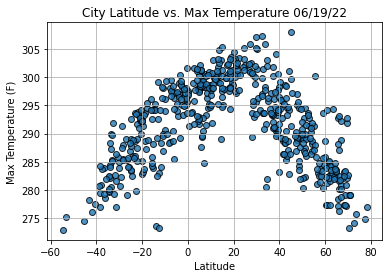

In [15]:
# Import time module.

import time

# Build the scatter plot for latitude vs. max temperature.

plt.scatter(lats,
           max_temps,
           edgecolor="black", linewidths=1, marker="o",
           alpha=0.8, label="Cities")

# Incorporate the other graph properties.

plt.title(f"City Latitude vs. Max Temperature "+ time.strftime('%x'))

plt.ylabel("Max Temperature (F)")

plt.xlabel("Latitude")

plt.grid(True)


# Save the figure.

plt.savefig("weather_data/Fig1.png")


# Show plot.

plt.show()

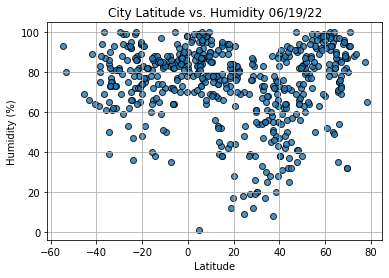

In [16]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            humidity,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Humidity "+ time.strftime("%x"))
plt.ylabel("Humidity (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig2.png")
# Show plot.
plt.show()

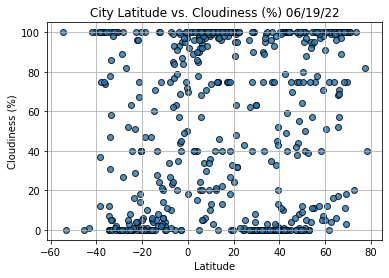

In [17]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            cloudiness,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Cloudiness (%) "+ time.strftime("%x"))
plt.ylabel("Cloudiness (%)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig3.png")
# Show plot.
plt.show()

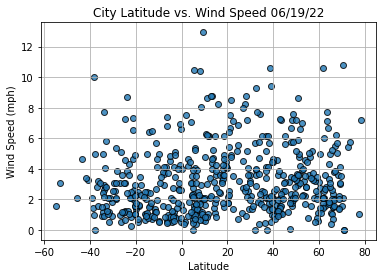

In [18]:
# Build the scatter plots for latitude vs. humidity.
plt.scatter(lats,
            wind_speed,
            edgecolor="black", linewidths=1, marker="o",
            alpha=0.8, label="Cities")

# Incorporate the other graph properties.
plt.title(f"City Latitude vs. Wind Speed "+ time.strftime("%x"))
plt.ylabel("Wind Speed (mph)")
plt.xlabel("Latitude")
plt.grid(True)
# Save the figure.
plt.savefig("weather_data/Fig4.png")
# Show plot.
plt.show()

In [30]:
# Import linregress

from scipy.stats import linregress


# Create a function to create perform linear regression on teh weather data
# and plot a regression line and the equation with the data.

def plot_linear_regression(x_values, y_values, title, y_label, text_coordinates):
    
    # Run regression on hemisphere weather data.
    
    (slope, intercept, r_value, p_value, std_err) = linregress(x_values, y_values)
    
    
    # Calculate the regression line "y values" from the slope and intercept.
    
    regress_values = x_values * slope + intercept
    
    
    # Get the equation of the line.
    
    line_eq = "y = " + str(round(slope,2)) + "x + " + str(round(intercept,2))
    
    
    # Create a scatter plot and plot the regression line.
    
    plt.scatter(x_values,y_values)
    
    plt.plot(x_values,regress_values,"r")
    
    
    # Annotate the text for the line equation.
    
    plt.annotate(line_eq, text_coordinates, fontsize=15, color="red")
    
    plt.title(title)
    
    plt.xlabel("Latitude")
    
    plt.ylabel(y_label)
    
    plt.show()

In [31]:
# Create Northern and Southern Hemisphere DataFrames.

northern_hemi_df = city_data_df.loc[(city_data_df["Lat"] >=0)]

southern_hemi_df = city_data_df.loc[(city_data_df["Lat"] <0)]

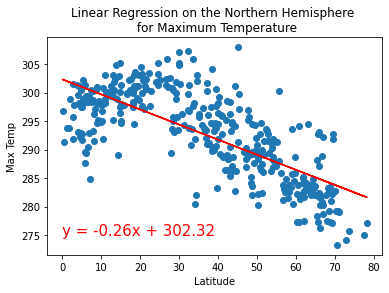

In [52]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Max Temp"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for Maximum Temperature", "Max Temp",(0,275))

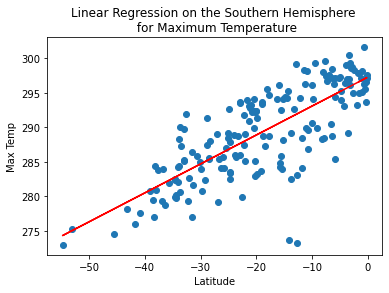

In [53]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Max Temp"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for Maximum Temperature", "Max Temp",(-60,90))

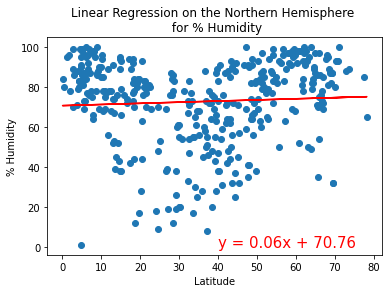

In [56]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Humidity"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for % Humidity", "% Humidity",(40,0))

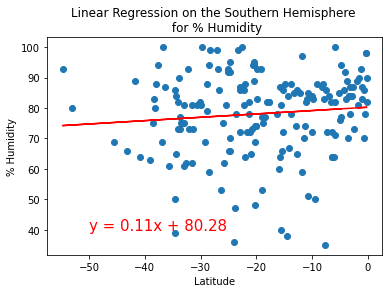

In [60]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Humidity"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for % Humidity", "% Humidity",(-50,40))

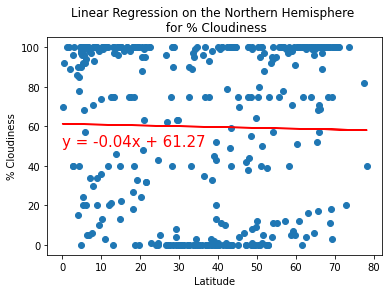

In [63]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Cloudiness"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for % Cloudiness", "% Cloudiness",(0,50))

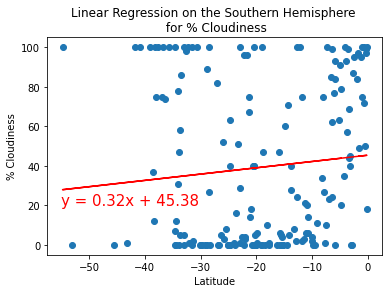

In [65]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Cloudiness"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for % Cloudiness", "% Cloudiness",(-55,20))

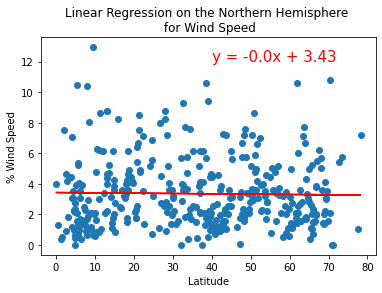

In [68]:
# Linear regression on the Northern Hemisphere.

x_values = northern_hemi_df["Lat"]

y_values = northern_hemi_df["Wind Speed"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Northern Hemisphere \n for Wind Speed", "% Wind Speed",(40,12))

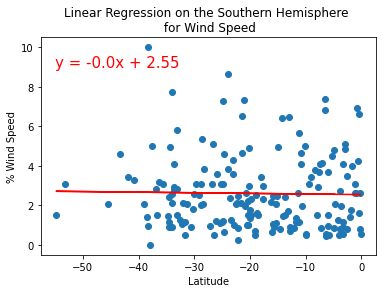

In [74]:
# Linear regression on the Southern Hemisphere.

x_values = southern_hemi_df["Lat"]

y_values = southern_hemi_df["Wind Speed"]

# Call the function.

plot_linear_regression(x_values, y_values,
                      "Linear Regression on the Southern Hemisphere \n for Wind Speed", "% Wind Speed",(-55,9))